In [1]:
import IJulia
import Base64

# The julia kernel has built in support for Revise.jl, so this is the 
# recommended approach for long-running sessions:
# https://github.com/JuliaLang/IJulia.jl/blob/9b10fa9b879574bbf720f5285029e07758e50a5e/src/kernel.jl#L46-L51

# Users should enable revise within .julia/config/startup_ijulia.jl:
# https://timholy.github.io/Revise.jl/stable/config/#Using-Revise-automatically-within-Jupyter/IJulia-1

# clear console history
IJulia.clear_history()

fig_width = 5.5
fig_height = 3.5
fig_format = :png
fig_dpi = 300

# no retina format type, use svg for high quality type/marks
if fig_format == :retina
  fig_format = :svg
elseif fig_format == :pdf
  fig_dpi = 96
  # Enable PDF support for IJulia
  IJulia.register_mime(MIME("application/pdf"))
end

# convert inches to pixels
fig_width = fig_width * fig_dpi
fig_height = fig_height * fig_dpi

# Intialize Plots w/ default fig width/height
try
  import Plots

  # Plots.jl doesn't support PDF output for versions < 1.28.1
  # so use png (if the DPI remains the default of 300 then set to 96)
  if (Plots._current_plots_version < v"1.28.1") & (fig_format == :pdf)
    Plots.gr(size=(fig_width, fig_height), fmt = :png, dpi = fig_dpi)
  else
    Plots.gr(size=(fig_width, fig_height), fmt = fig_format, dpi = fig_dpi)
  end
catch e
  # @warn "Plots init" exception=(e, catch_backtrace())
end

# Initialize CairoMakie with default fig width/height
try
  import CairoMakie

  # CairoMakie's display() in PDF format opens an interactive window
  # instead of saving to the ipynb file, so we don't do that.
  # https://github.com/quarto-dev/quarto-cli/issues/7548
  if fig_format == :pdf
    CairoMakie.activate!(type = "png")
  else
    CairoMakie.activate!(type = string(fig_format))
  end
  CairoMakie.update_theme!(resolution=(fig_width, fig_height))
catch e
    # @warn "CairoMakie init" exception=(e, catch_backtrace())
end
  
# Set run_path if specified
try
  run_path = "L3J1bi9tZWRpYS9hbGYvZGF0b3MvbWlzcmVwb3NpdG9yaW9zL2RvY2VuY2lhL2VjdWFjaW9uZXMtZGlmZXJlbmNpYWxlcy1wcmFjdGljYXMtanVsaWE="
  if !isempty(run_path)
    run_path = String(Base64.base64decode(run_path))
    cd(run_path)
  end
catch e
  @warn "Run path init:" exception=(e, catch_backtrace())
end


# emulate old Pkg.installed beahvior, see
# https://discourse.julialang.org/t/how-to-use-pkg-dependencies-instead-of-pkg-installed/36416/9
import Pkg
function isinstalled(pkg::String)
  any(x -> x.name == pkg && x.is_direct_dep, values(Pkg.dependencies()))
end

# ojs_define
if isinstalled("JSON") && isinstalled("DataFrames")
  import JSON, DataFrames
  global function ojs_define(; kwargs...)
    convert(x) = x
    convert(x::DataFrames.AbstractDataFrame) = Tables.rows(x)
    content = Dict("contents" => [Dict("name" => k, "value" => convert(v)) for (k, v) in kwargs])
    tag = "<script type='ojs-define'>$(JSON.json(content))</script>"
    IJulia.display(MIME("text/html"), tag)
  end
elseif isinstalled("JSON")
  import JSON
  global function ojs_define(; kwargs...)
    content = Dict("contents" => [Dict("name" => k, "value" => v) for (k, v) in kwargs])
    tag = "<script type='ojs-define'>$(JSON.json(content))</script>"
    IJulia.display(MIME("text/html"), tag)
  end
else
  global function ojs_define(; kwargs...)
    @warn "JSON package not available. Please install the JSON.jl package to use ojs_define."
  end
end


# don't return kernel dependencies (b/c Revise should take care of dependencies)
nothing


In [2]:
#| echo: false
#| include: false
packages = ["SymPyPythonCall", "Plots", "LaTeXStrings"]

3-element Vector{String}:
 "SymPyPythonCall"
 "Plots"
 "LaTeXStrings"

In [3]:
#| echo: false
#| include: false
using Plots
# Plots y Makie generan además una representación text/html con la imagen en base64
# en una sola línea; con figuras grandes esa línea desborda la pila del conversor
# de Quarto a Markdown. La desactivamos y dejamos solo image/png.
Base.showable(::MIME"text/html", ::Plots.Plot) = false

In [4]:
#| echo: false
using Markdown
v = string(VERSION)
Markdown.parse("![](https://img.shields.io/badge/Julia-$(v)-9558B2?logo=julia)")

![](https://img.shields.io/badge/Julia-1.12.6-9558B2?logo=julia)


In [5]:
#| echo: false
using Markdown
v = string(VERSION)
Markdown.parse("**Versión de Julia:** $(v)")

**Versión de Julia:** 1.12.6


In [6]:
#| echo: false
#| include: false
import Pkg
active_project = Base.active_project()
global_env = joinpath(homedir(), ".julia", "environments", "v$(VERSION.major).$(VERSION.minor)", "Project.toml")
Pkg.activate(global_env)

  Activating project at `~/.julia/environments/v1.12`


In [7]:
#| echo: false
Pkg.status(packages)

Status `~/.julia/environments/v1.12/Project.toml`
  [b964fa9f] LaTeXStrings v1.4.0
  [91a5bcdd] Plots v1.41.6
  [bc8888f7] SymPyPythonCall v0.5.1


In [8]:
#| echo: false
#| include: false
#Pkg.activate(active_project)

In [9]:
using SymPyPythonCall
@syms x t
u = exp(-(x - 2t - 5)^2)
simplify(diff(u, t) + 2 * diff(u, x))

0

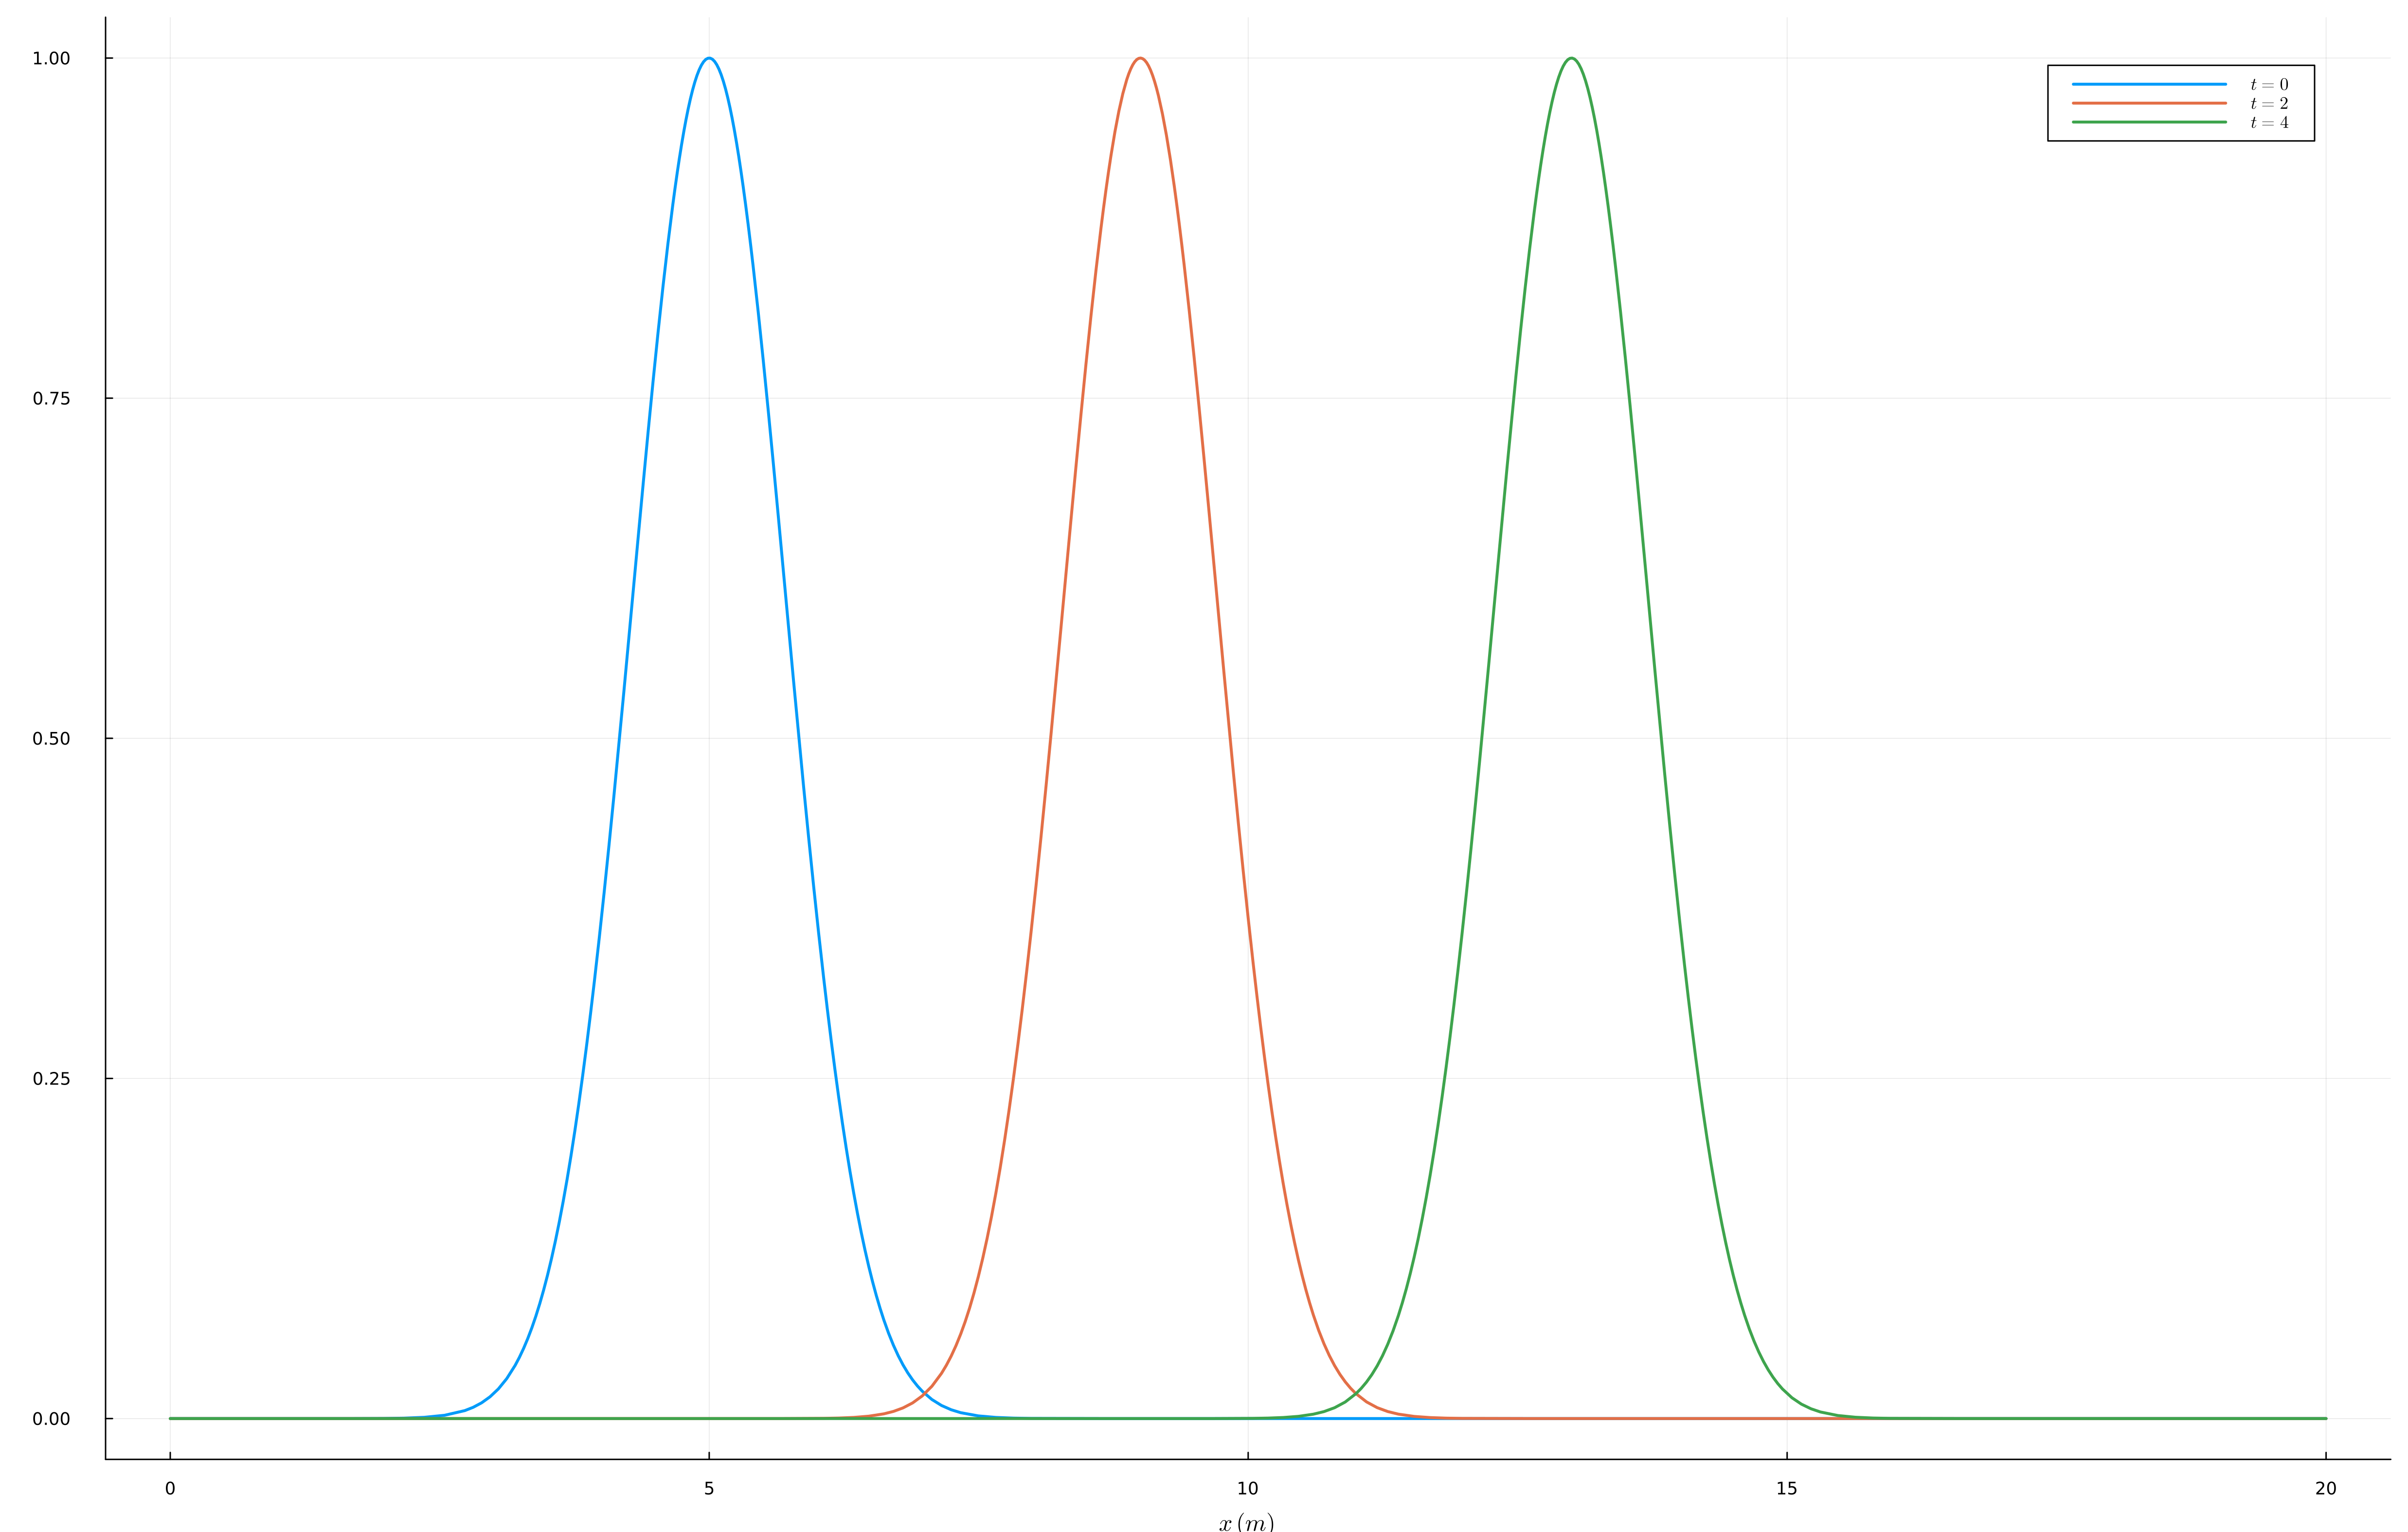

In [10]:
using Plots, LaTeXStrings
u0(ξ) = exp(-(ξ - 5)^2)
usol(x, t) = u0(x - 2t)
plt = plot(xlab = L"x \; (m)", ylab = "Concentración")
for τ in (0, 2, 4)
    plot!(plt, x -> usol(x, τ), 0, 20, lw = 2, label = L"t=%$τ")
end
plt

In [11]:
#| eval: false
anim = @animate for τ in 0:0.1:6
    plot(x -> usol(x, τ), 0, 20, lw = 2, ylims = (0, 1.1), legend = false,
         xlab = L"x", ylab = "Concentración", title = "t = $(round(τ,digits=1)) s")
end
gif(anim, "transporte.gif", fps = 15)

In [12]:
using SymPyPythonCall
@syms x t
u = 1 / (1 + (x * exp(-t))^2)
simplify(diff(u, t) + x * diff(u, x))

0

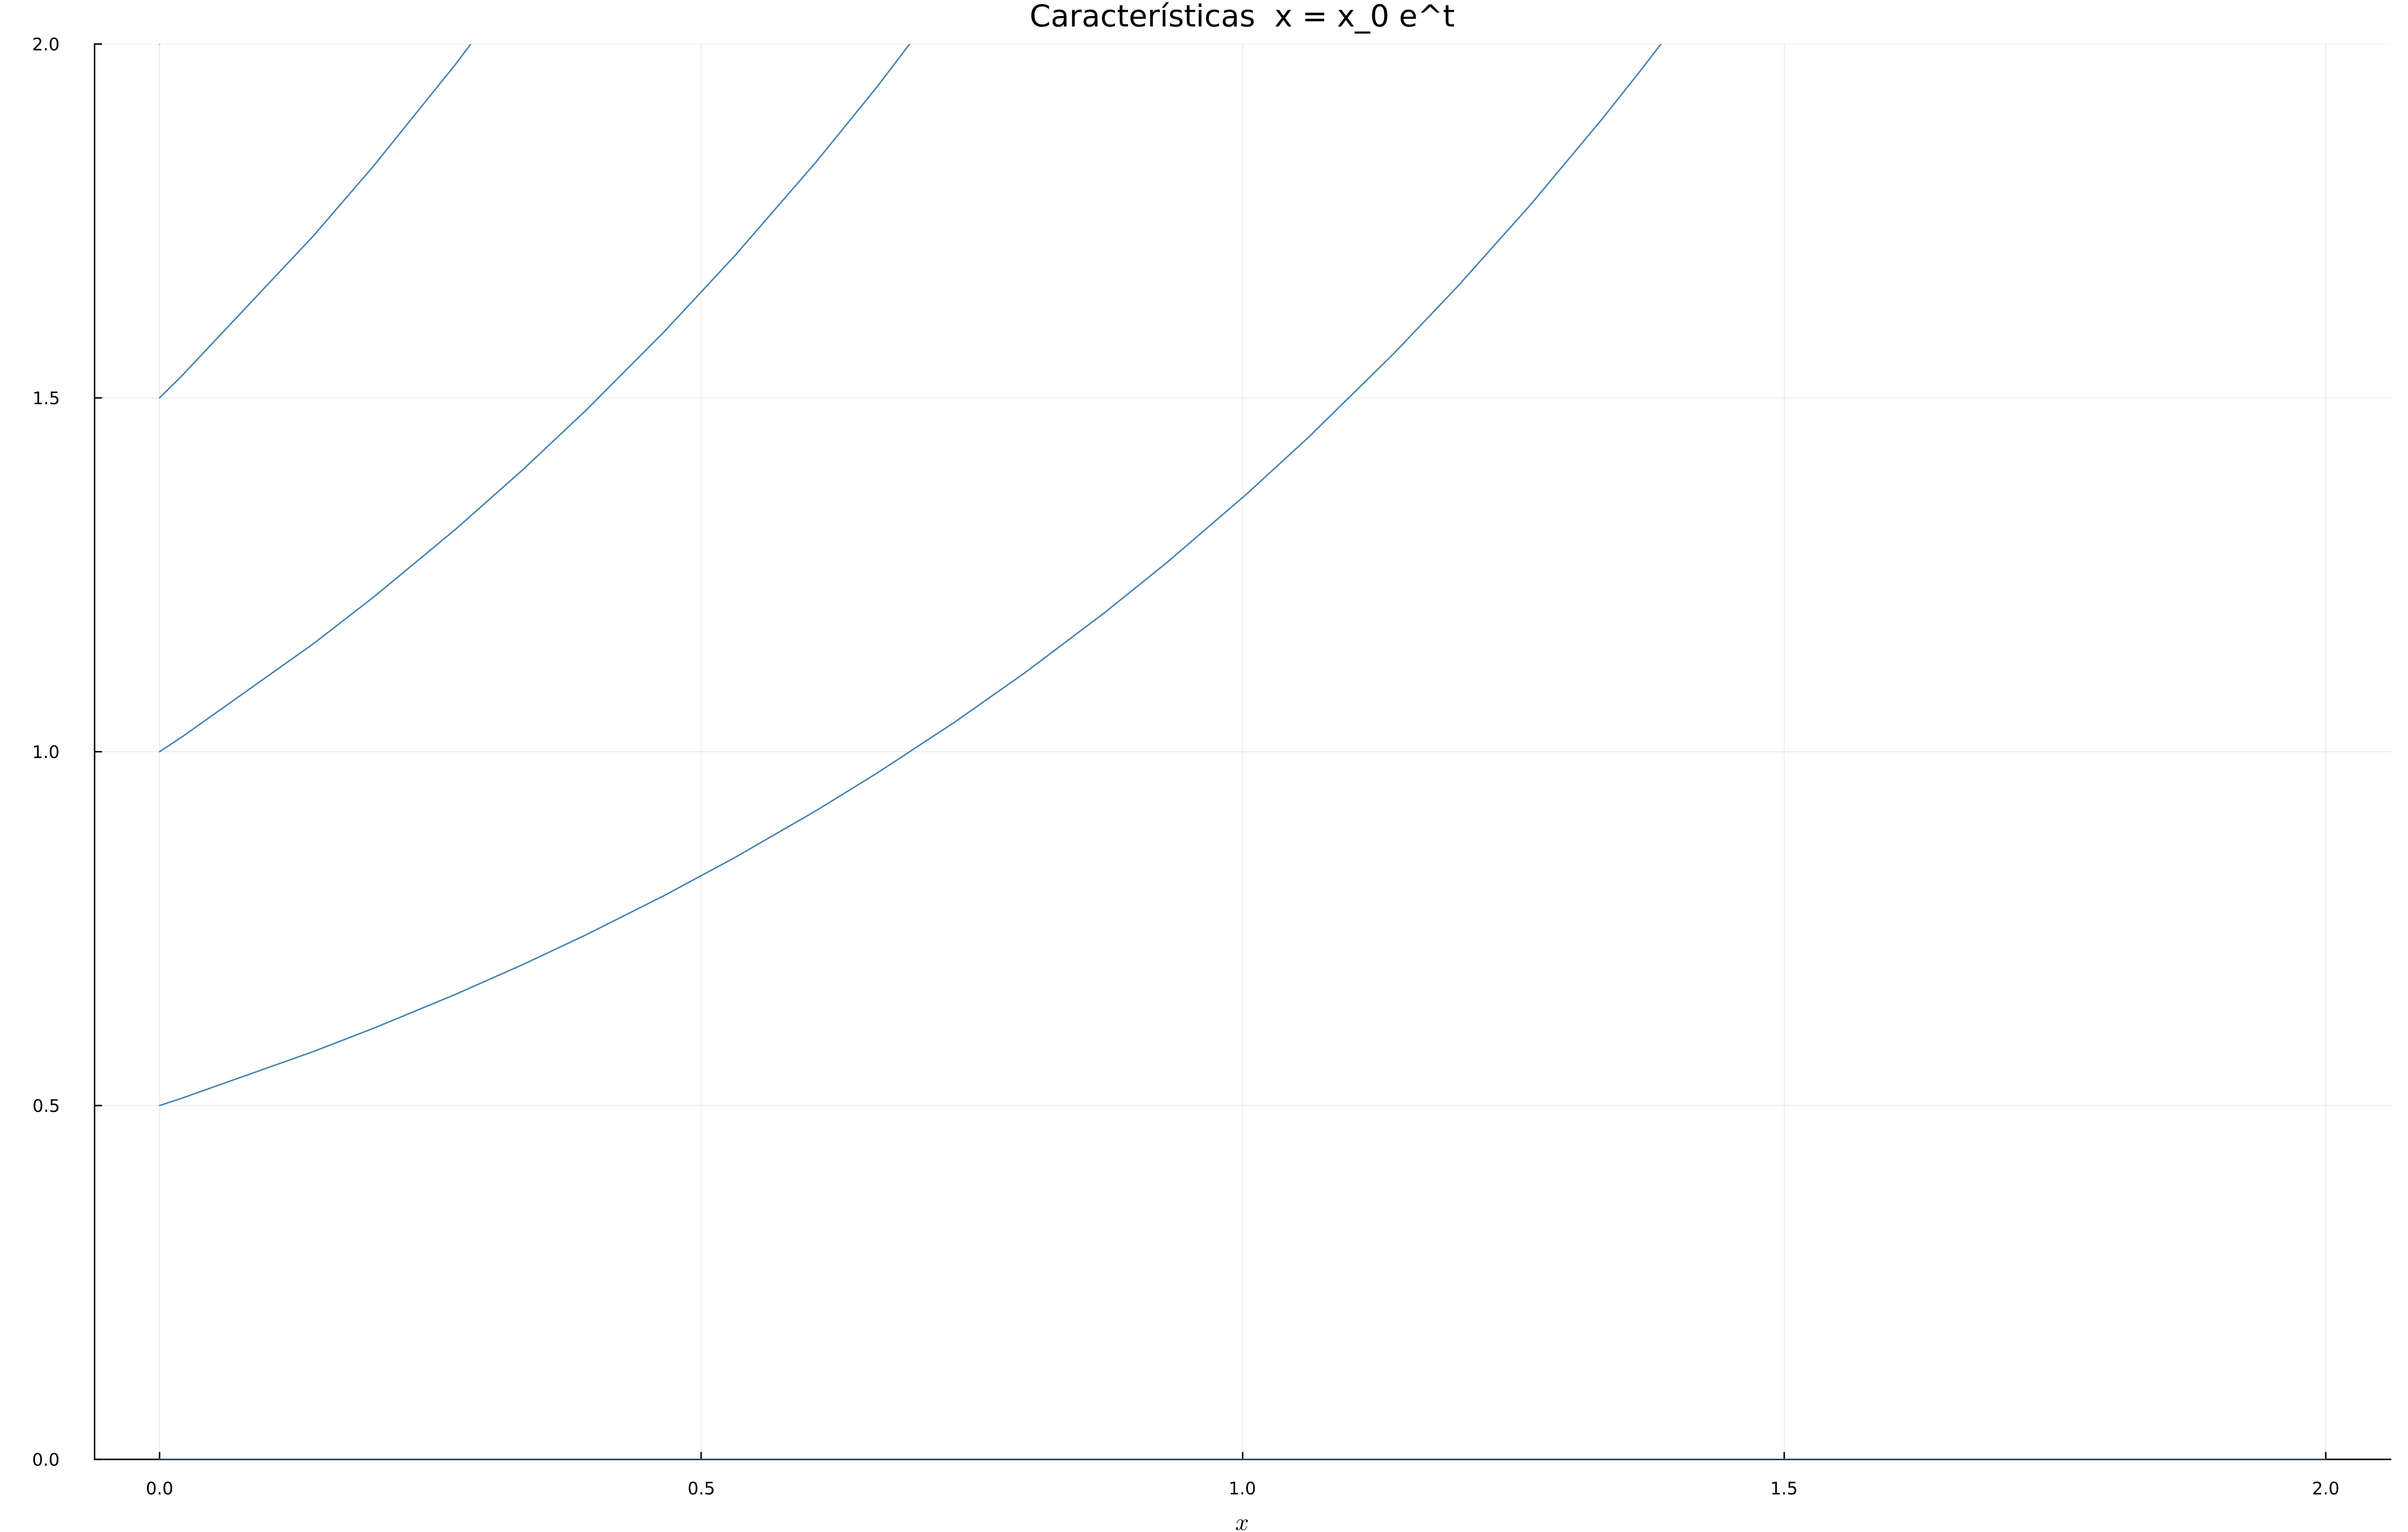

In [13]:
using Plots, LaTeXStrings
plt1 = plot(xlab = L"x", ylab = L"t", title = "Características  x = x_0 e^t",
            legend = false, ylims = (0, 2))
for x0 in -3:0.5:3
    plot!(plt1, τ -> x0 * exp(τ), 0, 2, color = :steelblue)
end
plt1

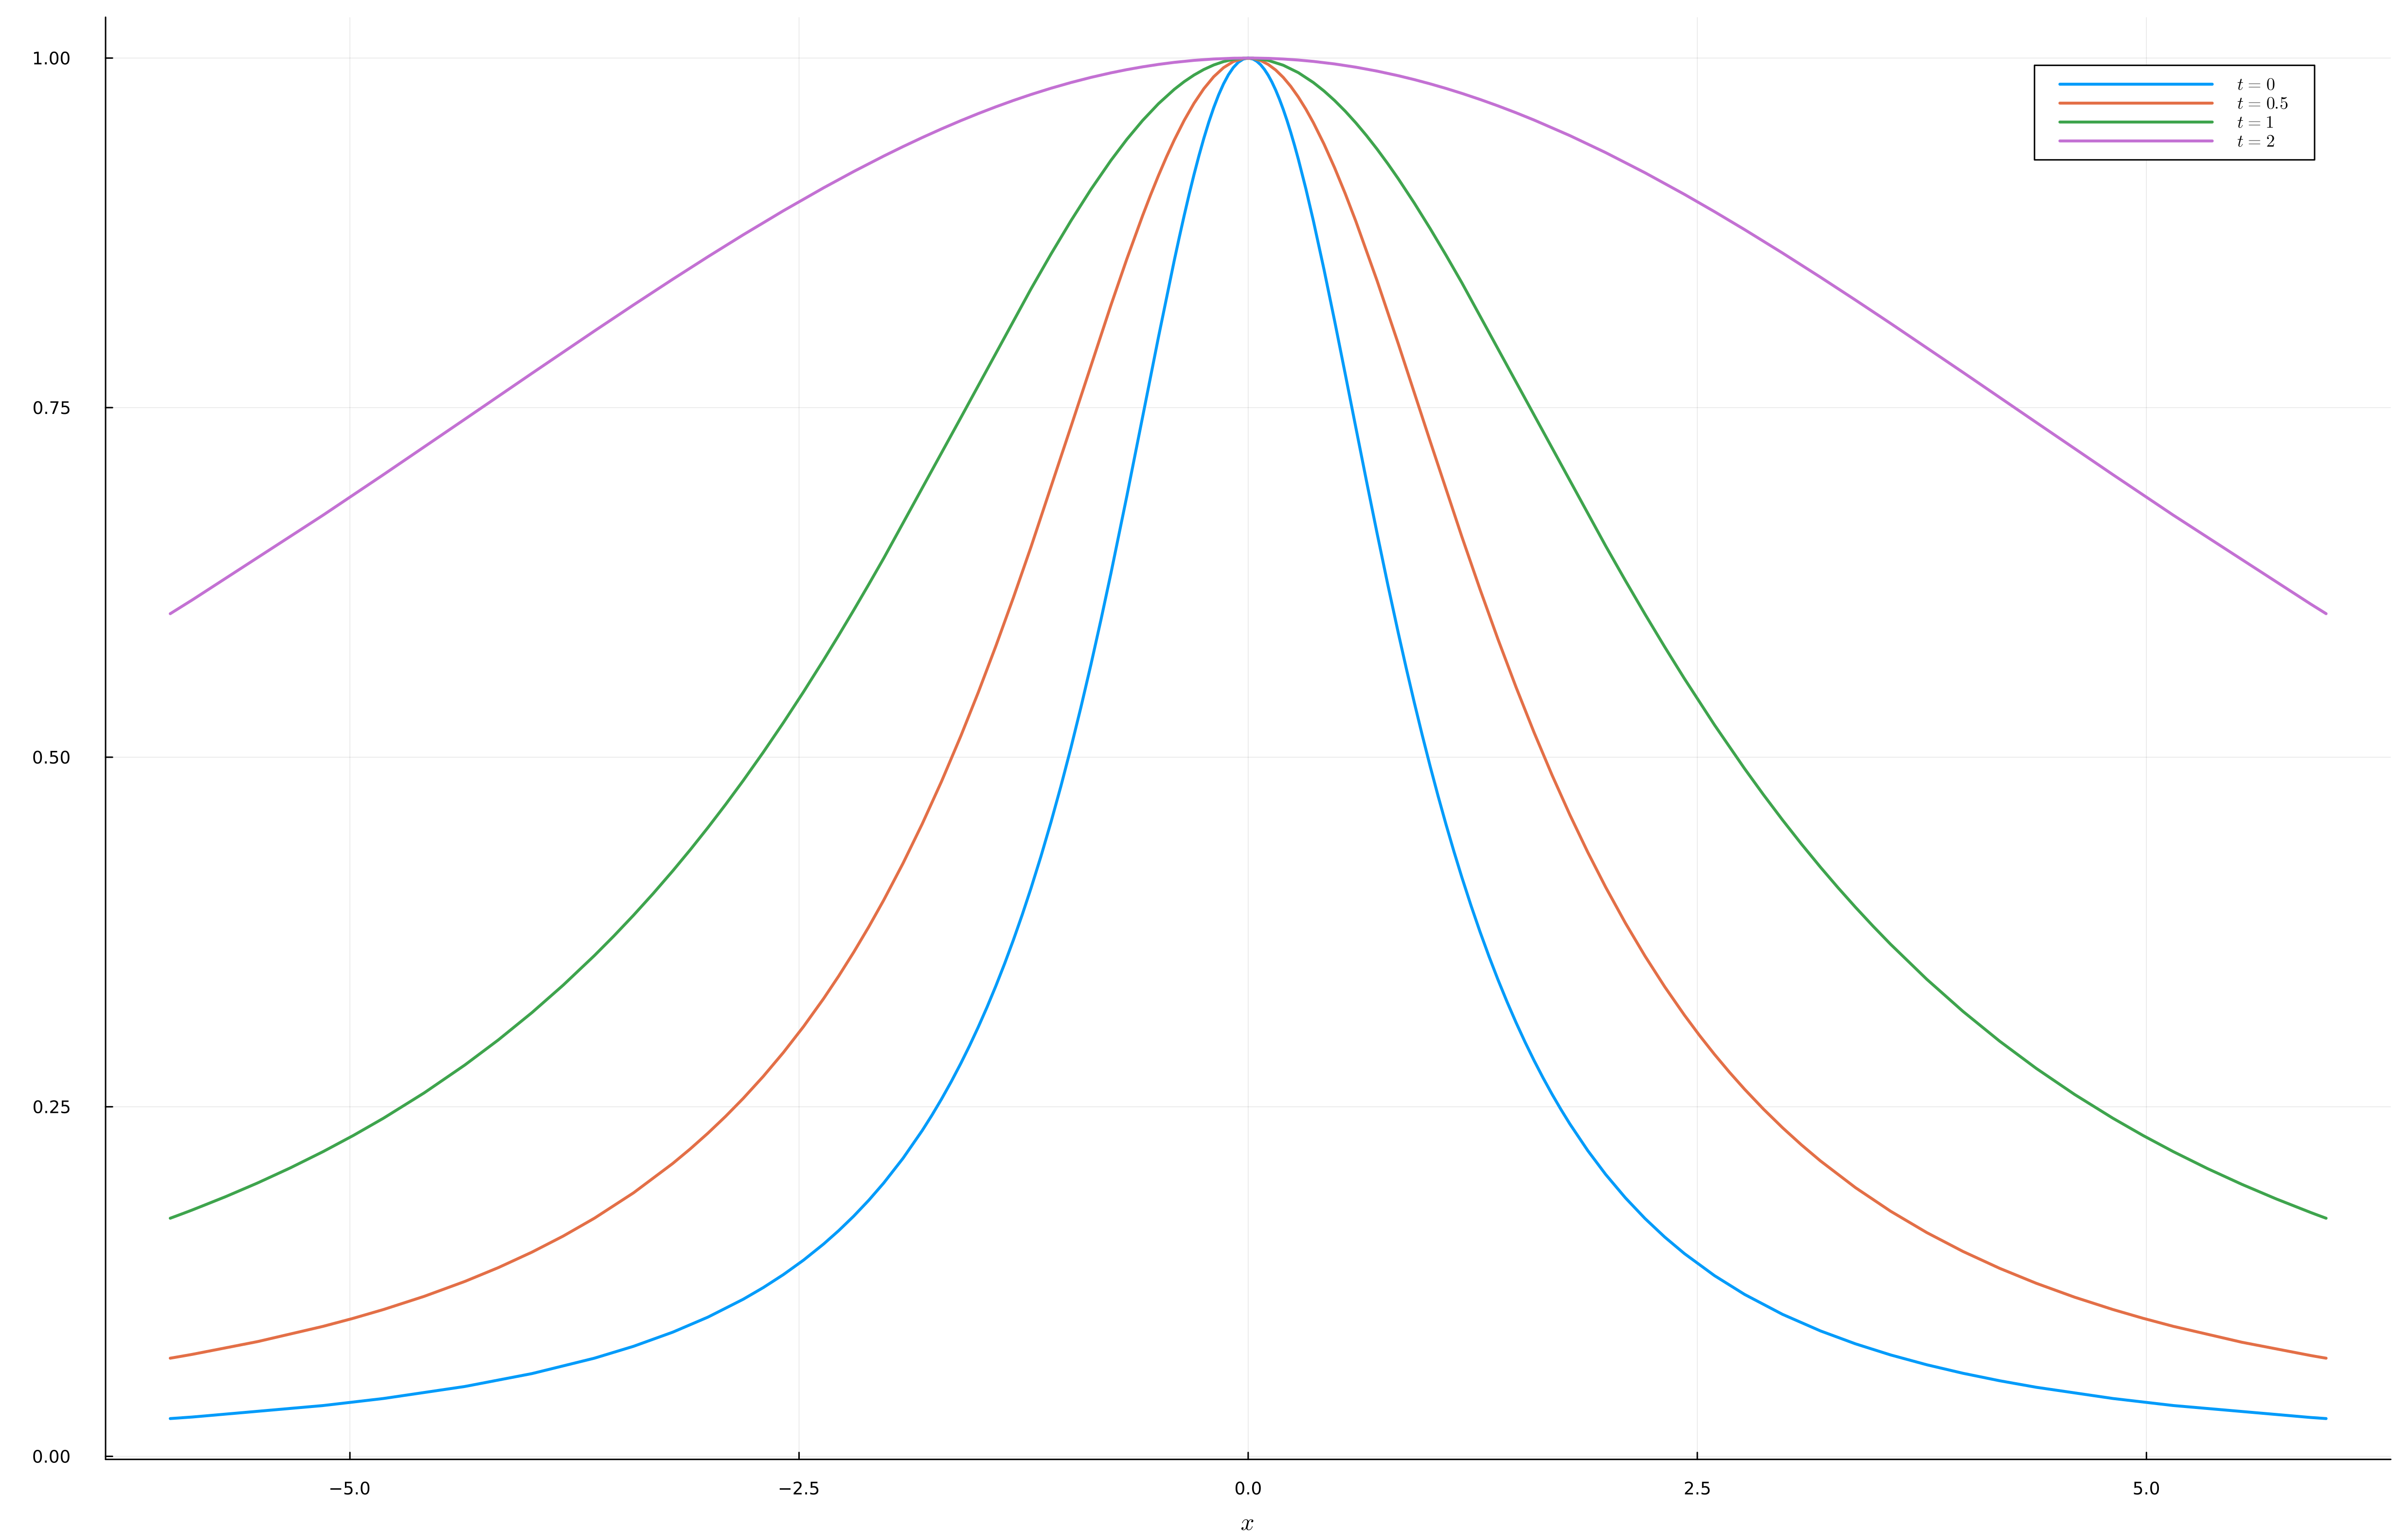

In [14]:
usol(x, t) = 1 / (1 + x^2 * exp(-2t))
plt2 = plot(xlab = L"x", ylab = L"u")
for τ in (0, 0.5, 1, 2)
    plot!(plt2, x -> usol(x, τ), -6, 6, lw = 2, label = L"t=%$τ")
end
plt2

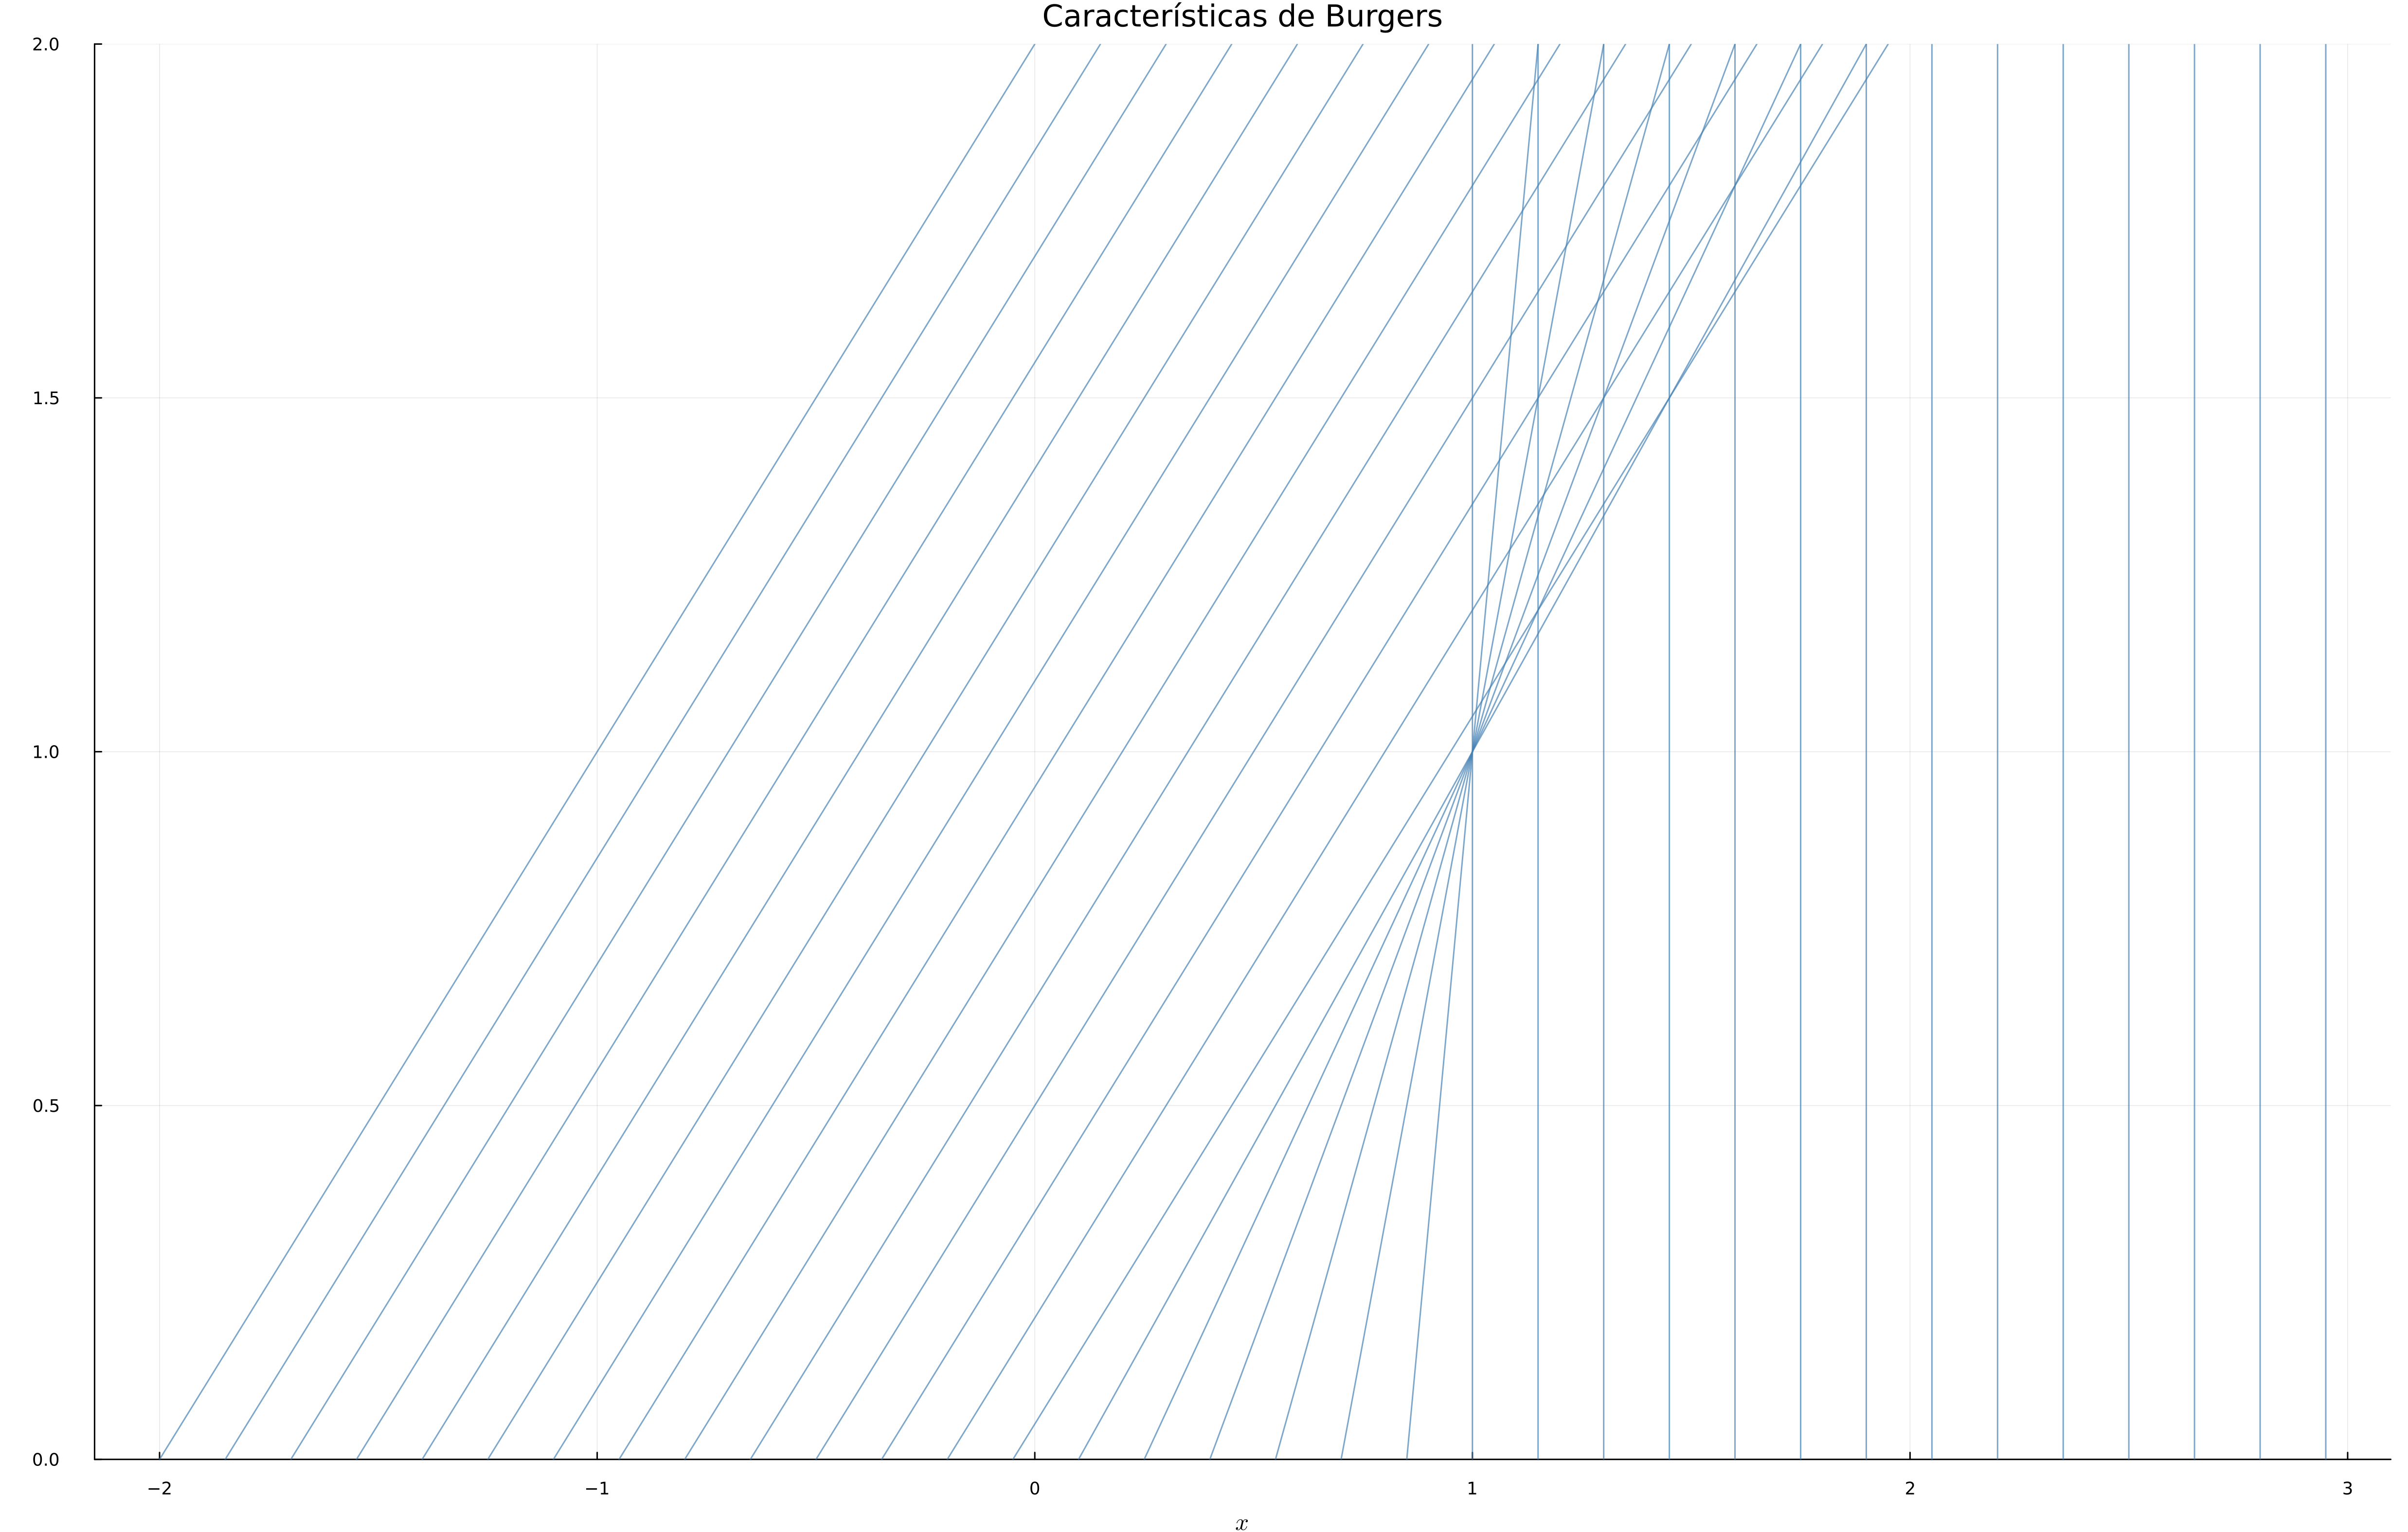

In [15]:
using Plots, LaTeXStrings
u0(x) = x < 0 ? 1.0 : (x <= 1 ? 1 - x : 0.0)
plt = plot(xlab = L"x", ylab = L"t", legend = false, ylims = (0, 2),
           title = "Características de Burgers")
for x0 in -2:0.15:3
    plot!(plt, [x0, x0 + u0(x0)*2], [0, 2], color = :steelblue, alpha = 0.7)
end
plt

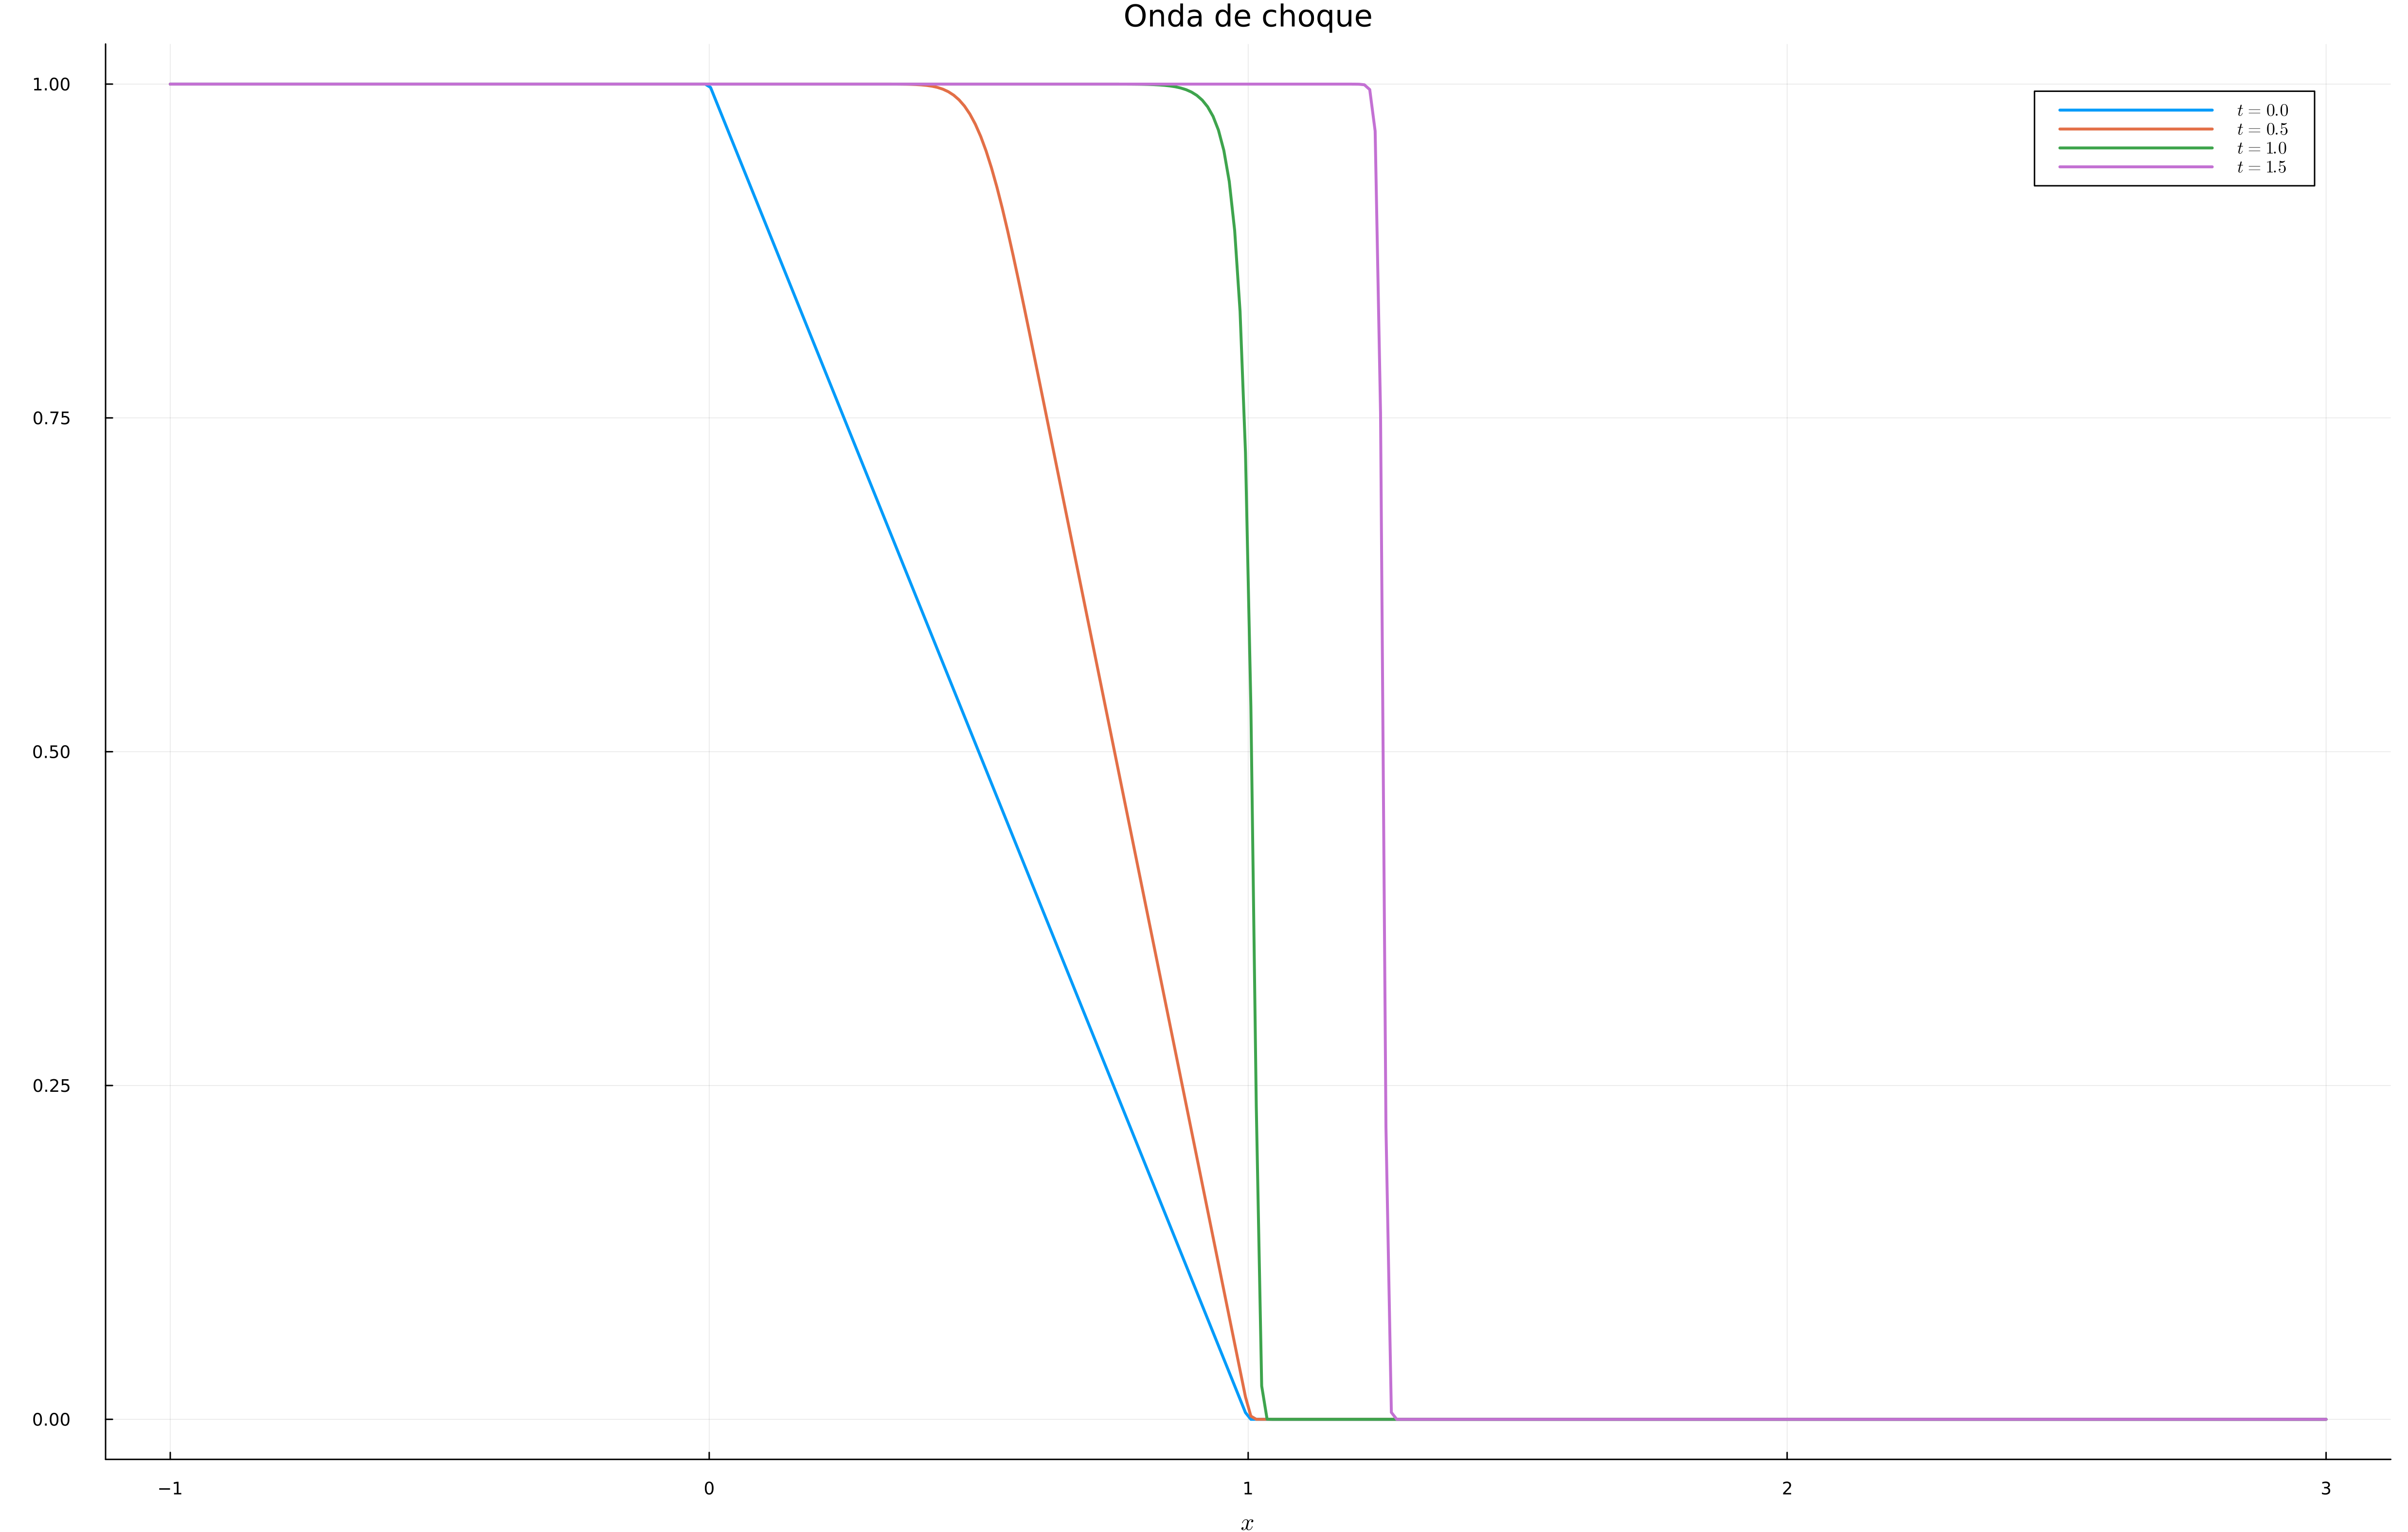

In [16]:
f(u) = 0.5u^2

# Flujo de Godunov para la ecuación de Burgers (f convexa).
function flujo(uL, uR)
    if uL <= uR                    # onda de rarefacción
        uL <= 0 <= uR ? f(0.0) : min(f(uL), f(uR))
    else                           # onda de choque
        max(f(uL), f(uR))
    end
end

function godunov_burgers(u0f, xs, T; cfl = 0.4)
    dx = xs[2] - xs[1]
    u = u0f.(xs)
    t = 0.0
    while t < T
        dt = cfl * dx / maximum(abs.(u) .+ 1e-9)
        dt = min(dt, T - t)
        F = [flujo(u[i], u[i+1]) for i in 1:length(u)-1]
        u[2:end-1] .-= dt/dx .* (F[2:end] .- F[1:end-1])
        t += dt
    end
    u
end

xs = range(-1, 3, length = 400)
plt = plot(xlab = L"x", ylab = L"u", title = "Onda de choque")
for T in (0.0, 0.5, 1.0, 1.5)
    u = godunov_burgers(u0, xs, T)
    plot!(plt, xs, u, lw = 2, label = L"t=%$T")
end
plt

In [17]:
using SymPyPythonCall
@syms x t
u = exp(-t) * cos(x - 3t)
simplify(diff(u, t) + 3 * diff(u, x) + u)

0

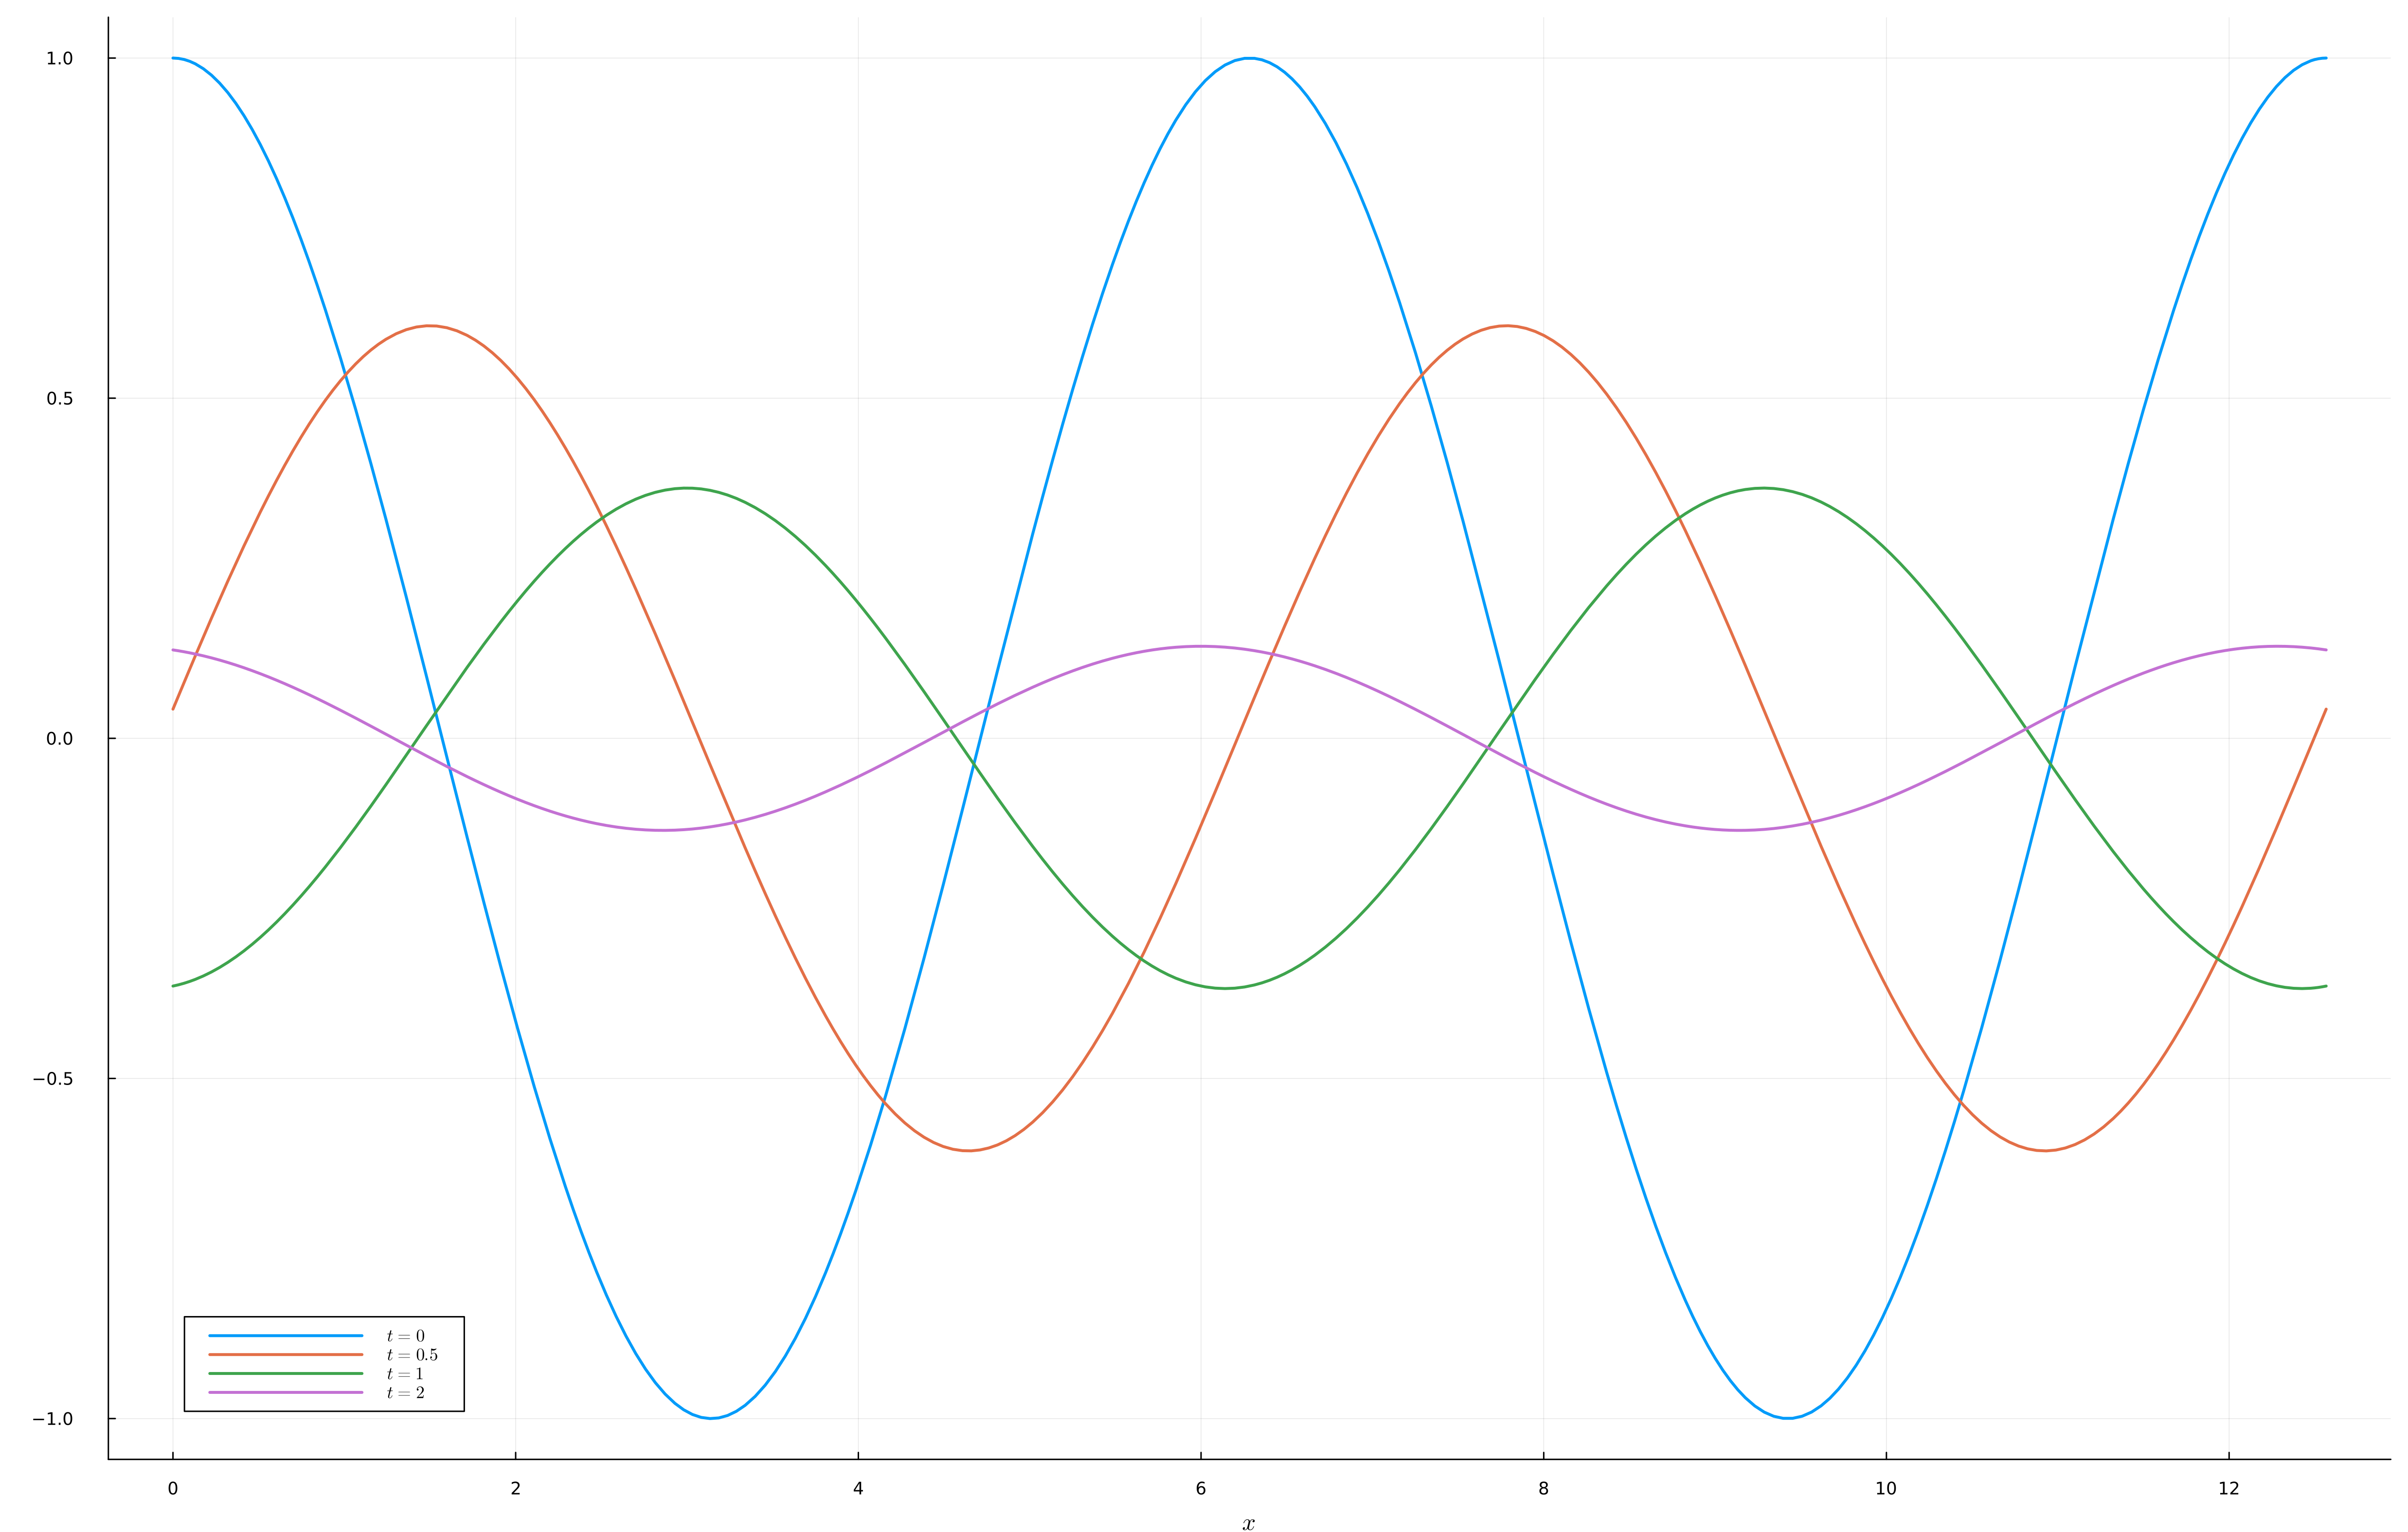

In [18]:
using Plots, LaTeXStrings
usol(x, t) = exp(-t) * cos(x - 3t)
plt = plot(xlab = L"x", ylab = L"u")
for τ in (0, 0.5, 1, 2)
    plot!(plt, x -> usol(x, τ), 0, 4π, lw = 2, label = L"t=%$τ")
end
plt